## 🏆 Smart Outcome Predictor: Student Performance and Course Completion Prediction Using Ensemble Machine Learning Techniques

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv('Smart_Outcome_Predictor_Dataset_5200.csv')

In [3]:
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [4]:
df.tail()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
5195,705196,28,Asia,Tablet,WorkingPro,Advanced,Data,2024-08-26,35,27,26.1,28,7,8,1,77.2,0.897,1,97.4
5196,705197,28,Africa,Tablet,Graduate,Beginner,Design,2024-04-27,17,21,3.9,31,8,4,0,82.4,0.743,1,71.9
5197,705198,22,Asia,Laptop,Undergrad,Intermediate,Marketing,2024-08-01,31,32,12.8,43,7,2,0,62.4,0.757,1,71.5
5198,705199,25,Asia,Laptop,Graduate,Beginner,Programming,2024-01-18,3,16,27.1,21,5,8,2,76.1,0.847,0,86.8
5199,705200,26,Europe,Mobile,HighSchool,Intermediate,Data,2024-12-24,52,20,28.8,37,11,5,3,NaN,0.768,0,67.9


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   str    
 3   device_type            5200 non-null   str    
 4   education_background   5200 non-null   str    
 5   course_level           5200 non-null   str    
 6   course_category        5200 non-null   str    
 7   course_start_date      5200 non-null   str    
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_quiz_score 

In [6]:
df.describe()

,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
count,5200.000000,5200.000000,5200.000000,5200.000000,5088.000000,5200.000000,5200.000000,5200.000000,5200.000000,5119.000000,5120.000000,5200.000000,5200.000000
mean,702600.500000,24.339615,26.621538,19.121923,18.216156,25.852885,6.995769,3.835769,1.585577,66.842626,0.847189,0.375385,74.821615
std,1501.255031,5.578864,15.007731,10.726708,10.734114,17.720493,2.568017,1.951802,1.270640,13.813992,0.113545,0.484269,13.531829
min,700001.000000,16.000000,1.000000,1.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.313000,0.000000,35.200000
25%,701300.750000,20.000000,14.000000,11.000000,10.300000,13.000000,5.000000,2.000000,1.000000,57.500000,0.768750,0.000000,64.700000
50%,702600.500000,24.000000,27.000000,17.000000,16.100000,23.000000,7.000000,4.000000,1.000000,66.900000,0.855000,0.000000,74.100000
75%,703900.250000,28.000000,40.000000,25.000000,23.800000,35.000000,9.000000,5.000000,2.000000,76.200000,0.942000,1.000000,84.900000
max,705200.000000,45.000000,52.000000,94.000000,76.800000,158.000000,20.000000,12.000000,8.000000,100.000000,1.000000,1.000000,100.000000


In [7]:
df.shape

(5200, 19)

In [8]:
df.isnull().sum()

student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
course_start_date          0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
dtype: int64

In [9]:
numerical_column = df.select_dtypes('number').columns.to_list()
numerical_column

['student_id',
 'age',
 'week_of_year',
 'sessions',
 'time_spent_hours',
 'videos_watched',
 'quiz_attempts',
 'assignments_submitted',
 'forum_posts',
 'avg_quiz_score',
 'attendance_rate',
 'completion_status',
 'final_score']

In [10]:
categorical_column = df.select_dtypes('string').columns.to_list()
categorical_column

['country_region',
 'device_type',
 'education_background',
 'course_level',
 'course_category',
 'course_start_date']

In [11]:
from sklearn.impute import SimpleImputer

In [12]:
median_imputer = SimpleImputer(strategy='median')

df[numerical_column] = median_imputer.fit_transform(df[numerical_column])

In [13]:
df.isnull().sum()

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64

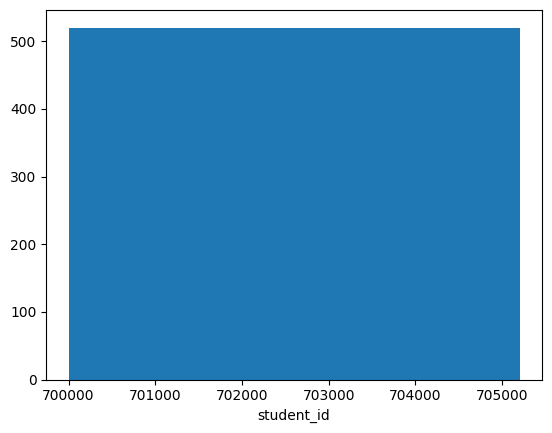

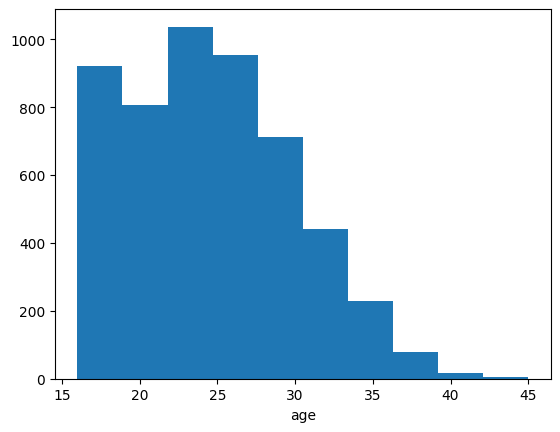

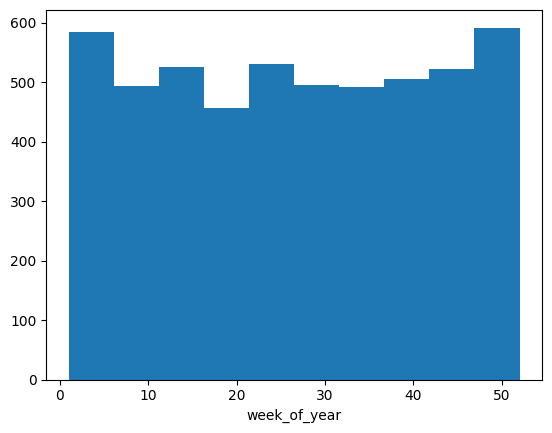

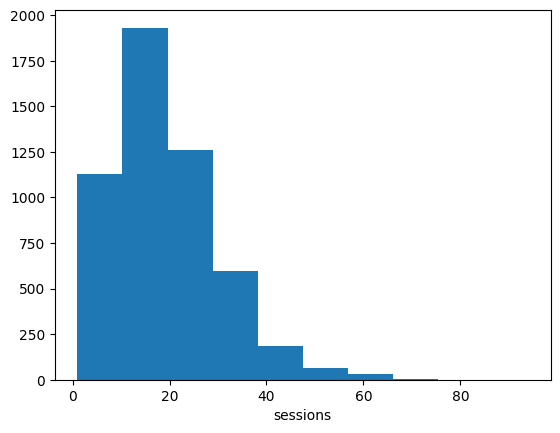

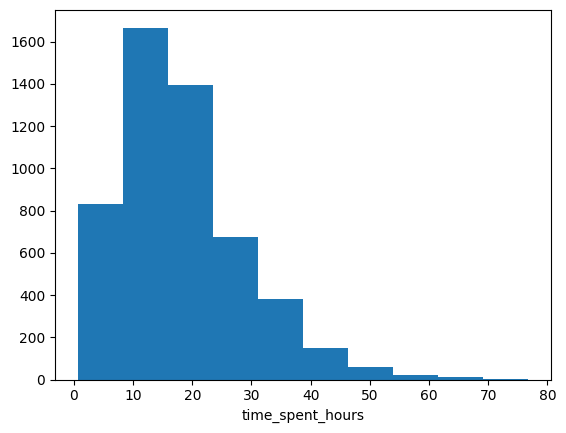

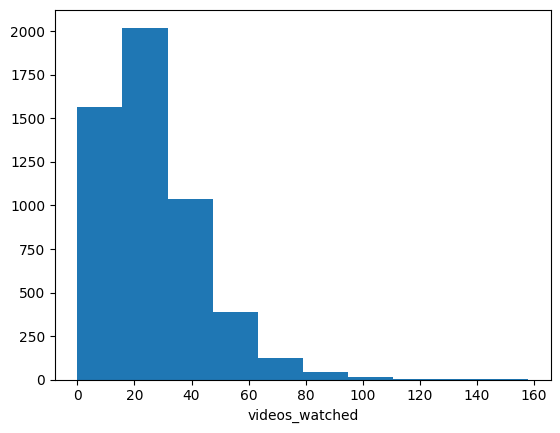

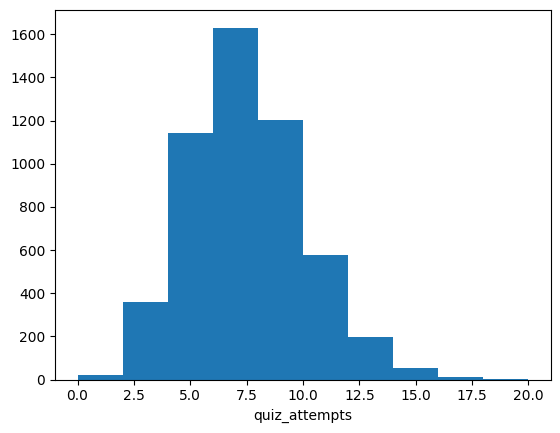

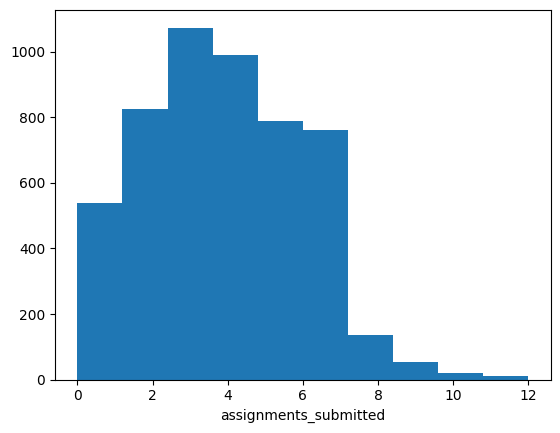

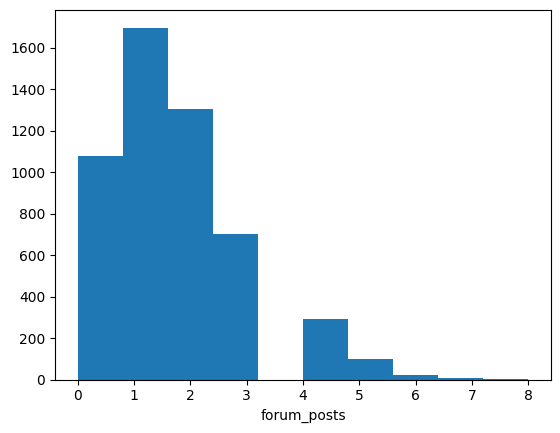

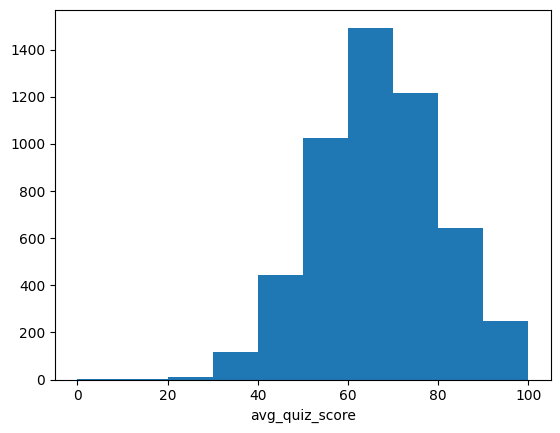

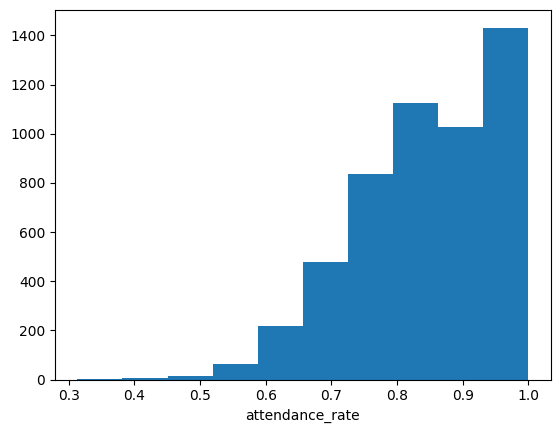

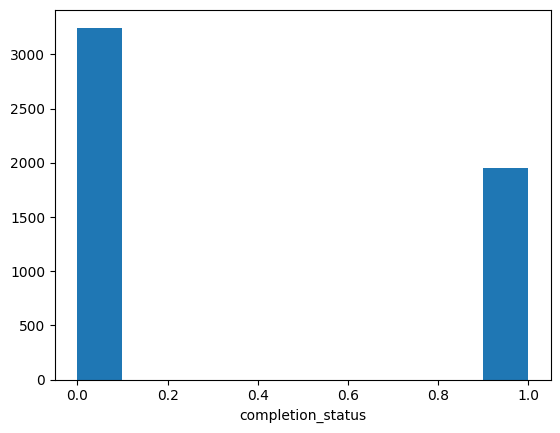

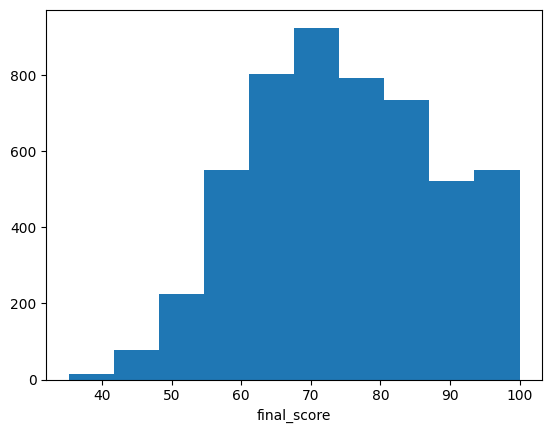

In [15]:
for cols in numerical_column:
    plt.hist(df[cols])
    plt.xlabel(cols)
    plt.show()

In [16]:
outliers_column = [
 'age',
 'sessions',
 'time_spent_hours',
 'videos_watched',
 'quiz_attempts',
 'assignments_submitted',
 'forum_posts',
 'avg_quiz_score',
 'attendance_rate'
 
 ]

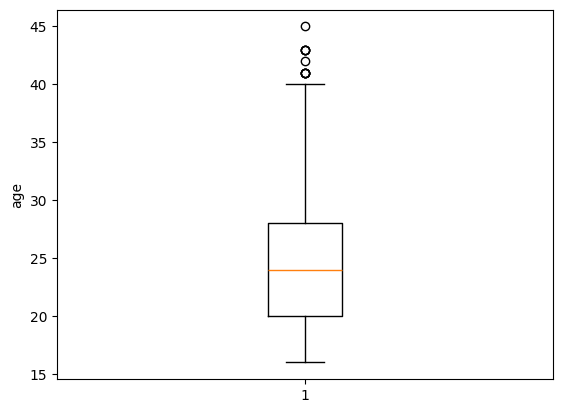

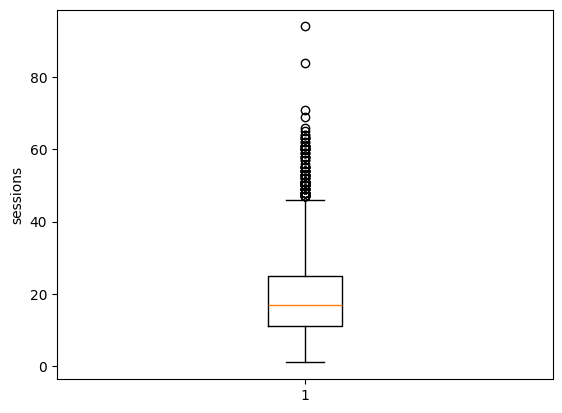

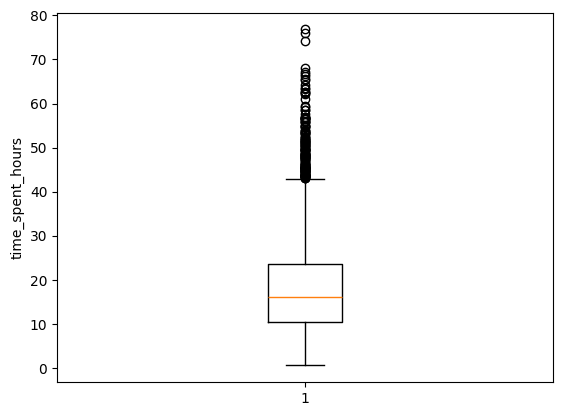

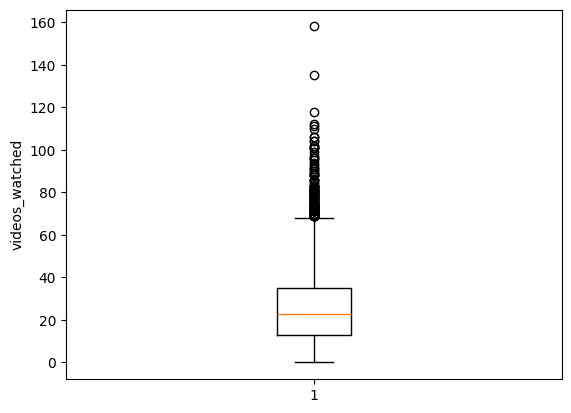

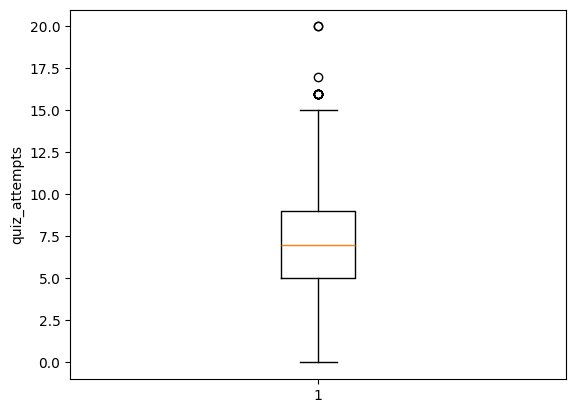

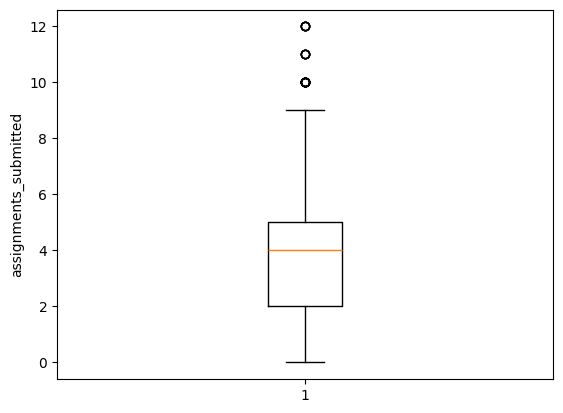

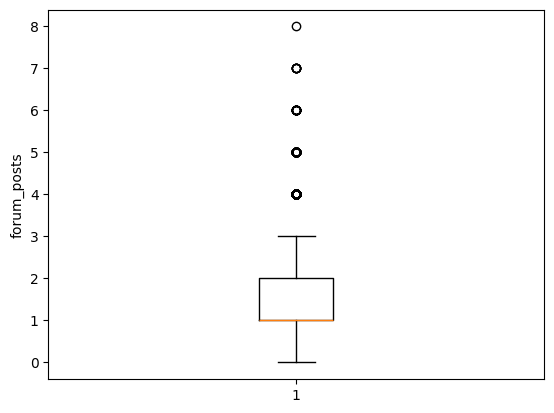

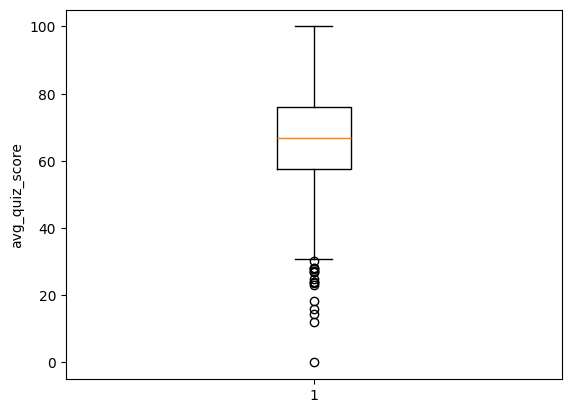

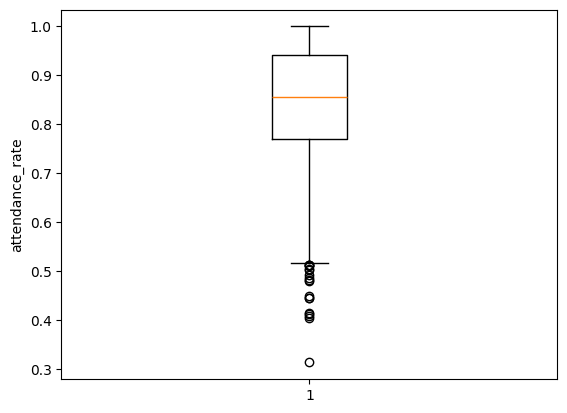

In [18]:
for cols in outliers_column:
    plt.boxplot(df[cols])
    plt.ylabel(cols)
    plt.show()

In [19]:
for cols in outliers_column:
     Q1 = df[cols].quantile(0.25)
     Q3 = df[cols].quantile(0.75)
     
     IQR = Q3 - Q1

     Lower = Q1 - (1.5 * IQR)
     
     Upper = Q3 + (1.5 * IQR)
     
     df = df[(df[cols] >= Lower) & (df[cols] <= Upper)]

In [20]:
df.shape

(4383, 19)

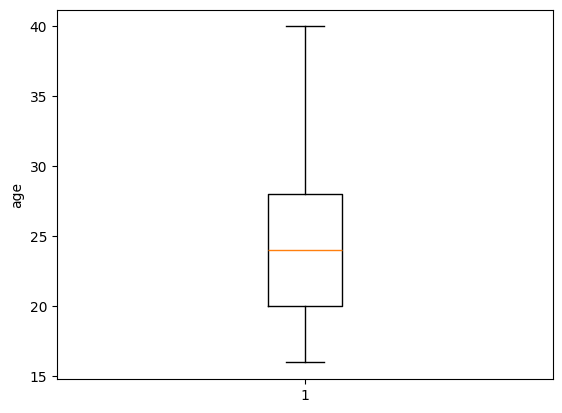

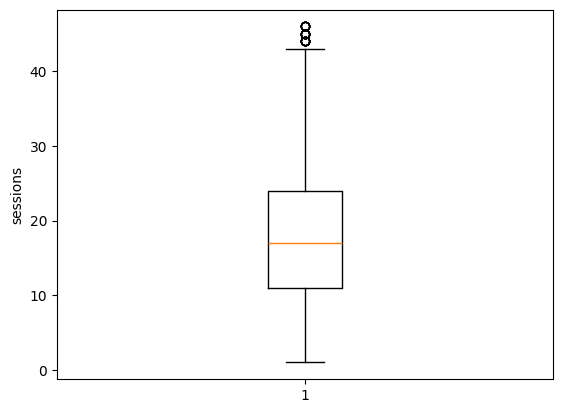

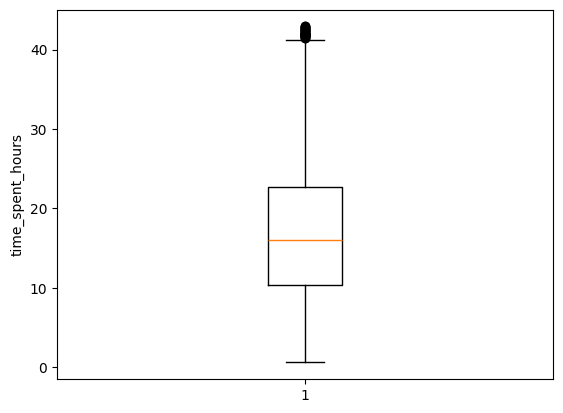

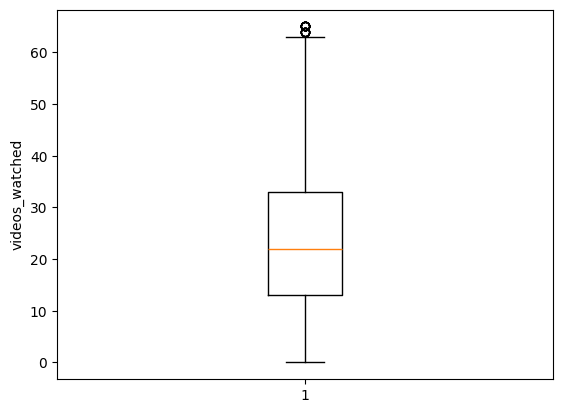

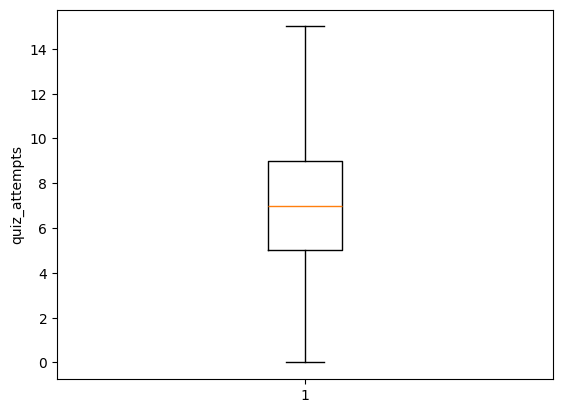

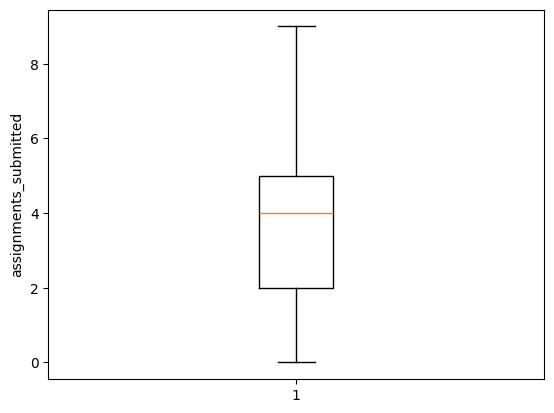

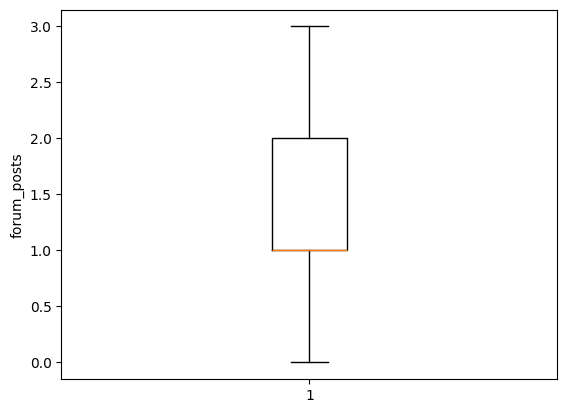

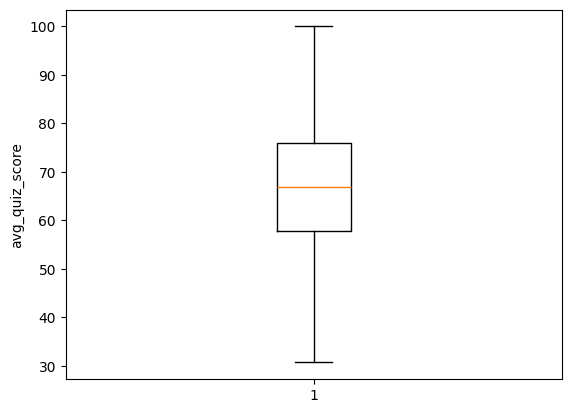

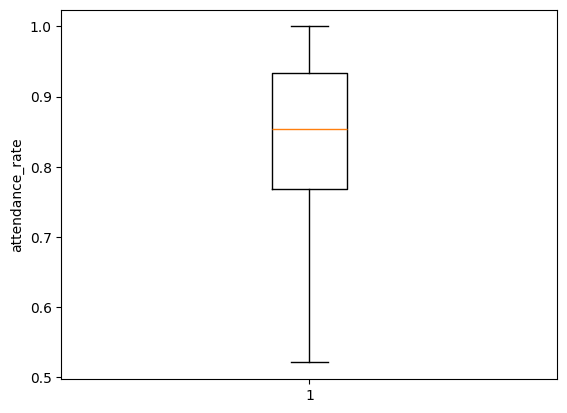

In [21]:
for cols in outliers_column:
    plt.boxplot(df[cols])
    plt.ylabel(cols)
    plt.show()

In [22]:
scaling_column = [
 'age',
 'week_of_year',
 'sessions',
 'time_spent_hours',
 'videos_watched',
 'quiz_attempts',
 'assignments_submitted',
 'forum_posts',
 'avg_quiz_score',
 'attendance_rate'
 ]

In [23]:
scaler = StandardScaler()

In [24]:
df[scaling_column] = scaler.fit_transform(df[scaling_column])

In [25]:
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001.0,1.395524,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,0.0,49.8
1,700002.0,-1.314686,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,1.0,84.0
2,700003.0,0.130760,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,0.0,62.5
3,700004.0,0.311440,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,1.0,89.5
4,700005.0,0.311440,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,0.0,67.4


In [26]:
cat_column = ['country_region',
 'device_type',
 'education_background',
 'course_level',
 'course_category'
 ]

In [27]:
df = pd.get_dummies(df,columns=cat_column,drop_first=False,dtype=int)

In [29]:
df.drop(['student_id','course_start_date'],axis=1,inplace=True)

In [30]:
df.head()

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,1.395524,-0.975477,-1.886282,-1.062757,-1.540257,-0.369750,-1.458420,-0.344933,-1.018644,-1.743625,...,1,0,0,0,1,1,0,0,0,0
1,-1.314686,0.493337,-0.213248,1.101746,-1.201238,-1.159715,1.706847,-0.344933,-1.153411,1.423907,...,1,0,0,0,1,0,0,0,0,1
2,0.130760,0.827158,-1.328604,-1.117974,-0.523201,-1.949681,-0.930876,-1.357553,-0.352295,-0.320531,...,0,0,1,0,0,0,0,0,0,1
3,0.311440,-1.109006,1.794392,0.538533,2.256752,0.815198,1.179302,-1.357553,-0.569420,0.276250,...,1,0,0,1,0,0,0,1,0,0
4,0.311440,-0.975477,0.455965,1.664958,1.171892,0.815198,-0.930876,-1.357553,-0.135170,-0.283806,...,0,1,1,0,0,1,0,0,0,0


In [31]:
df.to_csv('main_clean_data.csv',index=False)

In [33]:
print(df.duplicated().sum())

0


In [34]:
df.corr(numeric_only=True)['completion_status'].sort_values(ascending=False)

completion_status                  1.000000
final_score                        0.681098
avg_quiz_score                     0.341775
attendance_rate                    0.264186
sessions                           0.187358
time_spent_hours                   0.144723
videos_watched                     0.132907
assignments_submitted              0.058552
quiz_attempts                      0.038728
course_level_Beginner              0.032152
course_category_Design             0.031687
education_background_HighSchool    0.027061
country_region_Europe              0.025039
course_category_Business           0.020612
course_category_Marketing          0.014188
device_type_Tablet                 0.008171
country_region_Africa              0.005964
course_category_Programming        0.005646
week_of_year                       0.004273
age                                0.002423
education_background_WorkingPro    0.001586
device_type_Laptop                 0.000662
education_background_Graduate   

In [35]:
df.corr(numeric_only=True)['final_score'].sort_values(ascending=False)

final_score                        1.000000
completion_status                  0.681098
avg_quiz_score                     0.519097
attendance_rate                    0.298153
time_spent_hours                   0.279833
assignments_submitted              0.233360
sessions                           0.212111
videos_watched                     0.208557
forum_posts                        0.048634
quiz_attempts                      0.041138
course_category_Design             0.031635
country_region_Oceania             0.026587
device_type_Mobile                 0.021731
course_level_Beginner              0.017311
education_background_WorkingPro    0.013710
course_category_Marketing          0.011404
week_of_year                       0.011094
country_region_Europe              0.010313
education_background_Graduate      0.010022
course_category_Business           0.005364
course_category_Programming        0.003368
education_background_HighSchool    0.002970
country_region_Americas         

In [38]:
df.corr(numeric_only=True)

,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,...,education_background_Undergrad,education_background_WorkingPro,course_level_Advanced,course_level_Beginner,course_level_Intermediate,course_category_Business,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
age,1.000000,-0.002011,-0.009441,0.006009,0.008699,-0.025655,-0.012958,0.018930,-0.011874,-0.013365,...,0.006965,-0.007831,-0.008193,0.025624,-0.019701,0.013336,-0.013365,-0.002475,-0.006093,0.008727
week_of_year,-0.002011,1.000000,0.011109,-0.011242,0.015036,-0.008477,0.029165,0.014177,0.014831,0.012800,...,0.024236,-0.007569,-0.007083,0.021687,-0.016561,-0.013116,-0.008852,-0.020094,0.001843,0.035563
sessions,-0.009441,0.011109,1.000000,0.005609,0.753030,0.201270,0.023226,-0.005090,0.017615,0.266294,...,0.008338,0.023908,-0.031905,-0.008097,0.032340,-0.022501,-0.011440,-0.023104,0.007024,0.045046
time_spent_hours,0.006009,-0.011242,0.005609,1.000000,0.002453,-0.014990,0.227017,-0.011980,0.049980,0.000893,...,0.010366,-0.012889,0.020864,-0.002487,-0.013282,-0.001558,-0.003765,0.001681,0.007955,-0.002088
videos_watched,0.008699,0.015036,0.753030,0.002453,1.000000,0.152174,0.016749,0.007620,0.019095,0.194751,...,0.042147,0.001627,-0.021256,0.012388,0.003570,-0.015183,-0.022469,-0.005218,-0.005885,0.045479
quiz_attempts,-0.025655,-0.008477,0.201270,-0.014990,0.152174,1.000000,0.013648,0.014088,0.019610,0.061104,...,0.008541,0.004685,0.009272,0.009161,-0.016281,-0.005574,0.007078,0.004944,0.003029,-0.008708
assignments_submitted,-0.012958,0.029165,0.023226,0.227017,0.016749,0.013648,1.000000,0.015910,0.015167,0.018227,...,-0.003035,0.011616,0.002670,-0.004283,0.002308,-0.005184,0.002687,-0.010520,0.018349,-0.003679
forum_posts,0.018930,0.014177,-0.005090,-0.011980,0.007620,0.014088,0.015910,1.000000,-0.004858,-0.003256,...,0.008816,-0.014017,-0.003286,-0.004758,0.007297,0.010462,0.000675,-0.009615,0.008823,-0.008927
avg_quiz_score,-0.011874,0.014831,0.017615,0.049980,0.019095,0.019610,0.015167,-0.004858,1.000000,0.016647,...,-0.019978,-0.002951,-0.011147,-0.009039,0.017577,0.001791,0.002665,-0.002960,-0.001509,-0.000835
attendance_rate,-0.013365,0.012800,0.266294,0.000893,0.194751,0.061104,0.018227,-0.003256,0.016647,1.000000,...,-0.013027,0.017546,0.011943,0.014191,-0.023388,-0.004583,-0.008524,0.005868,-0.010840,0.016437


In [36]:
import seaborn as sns

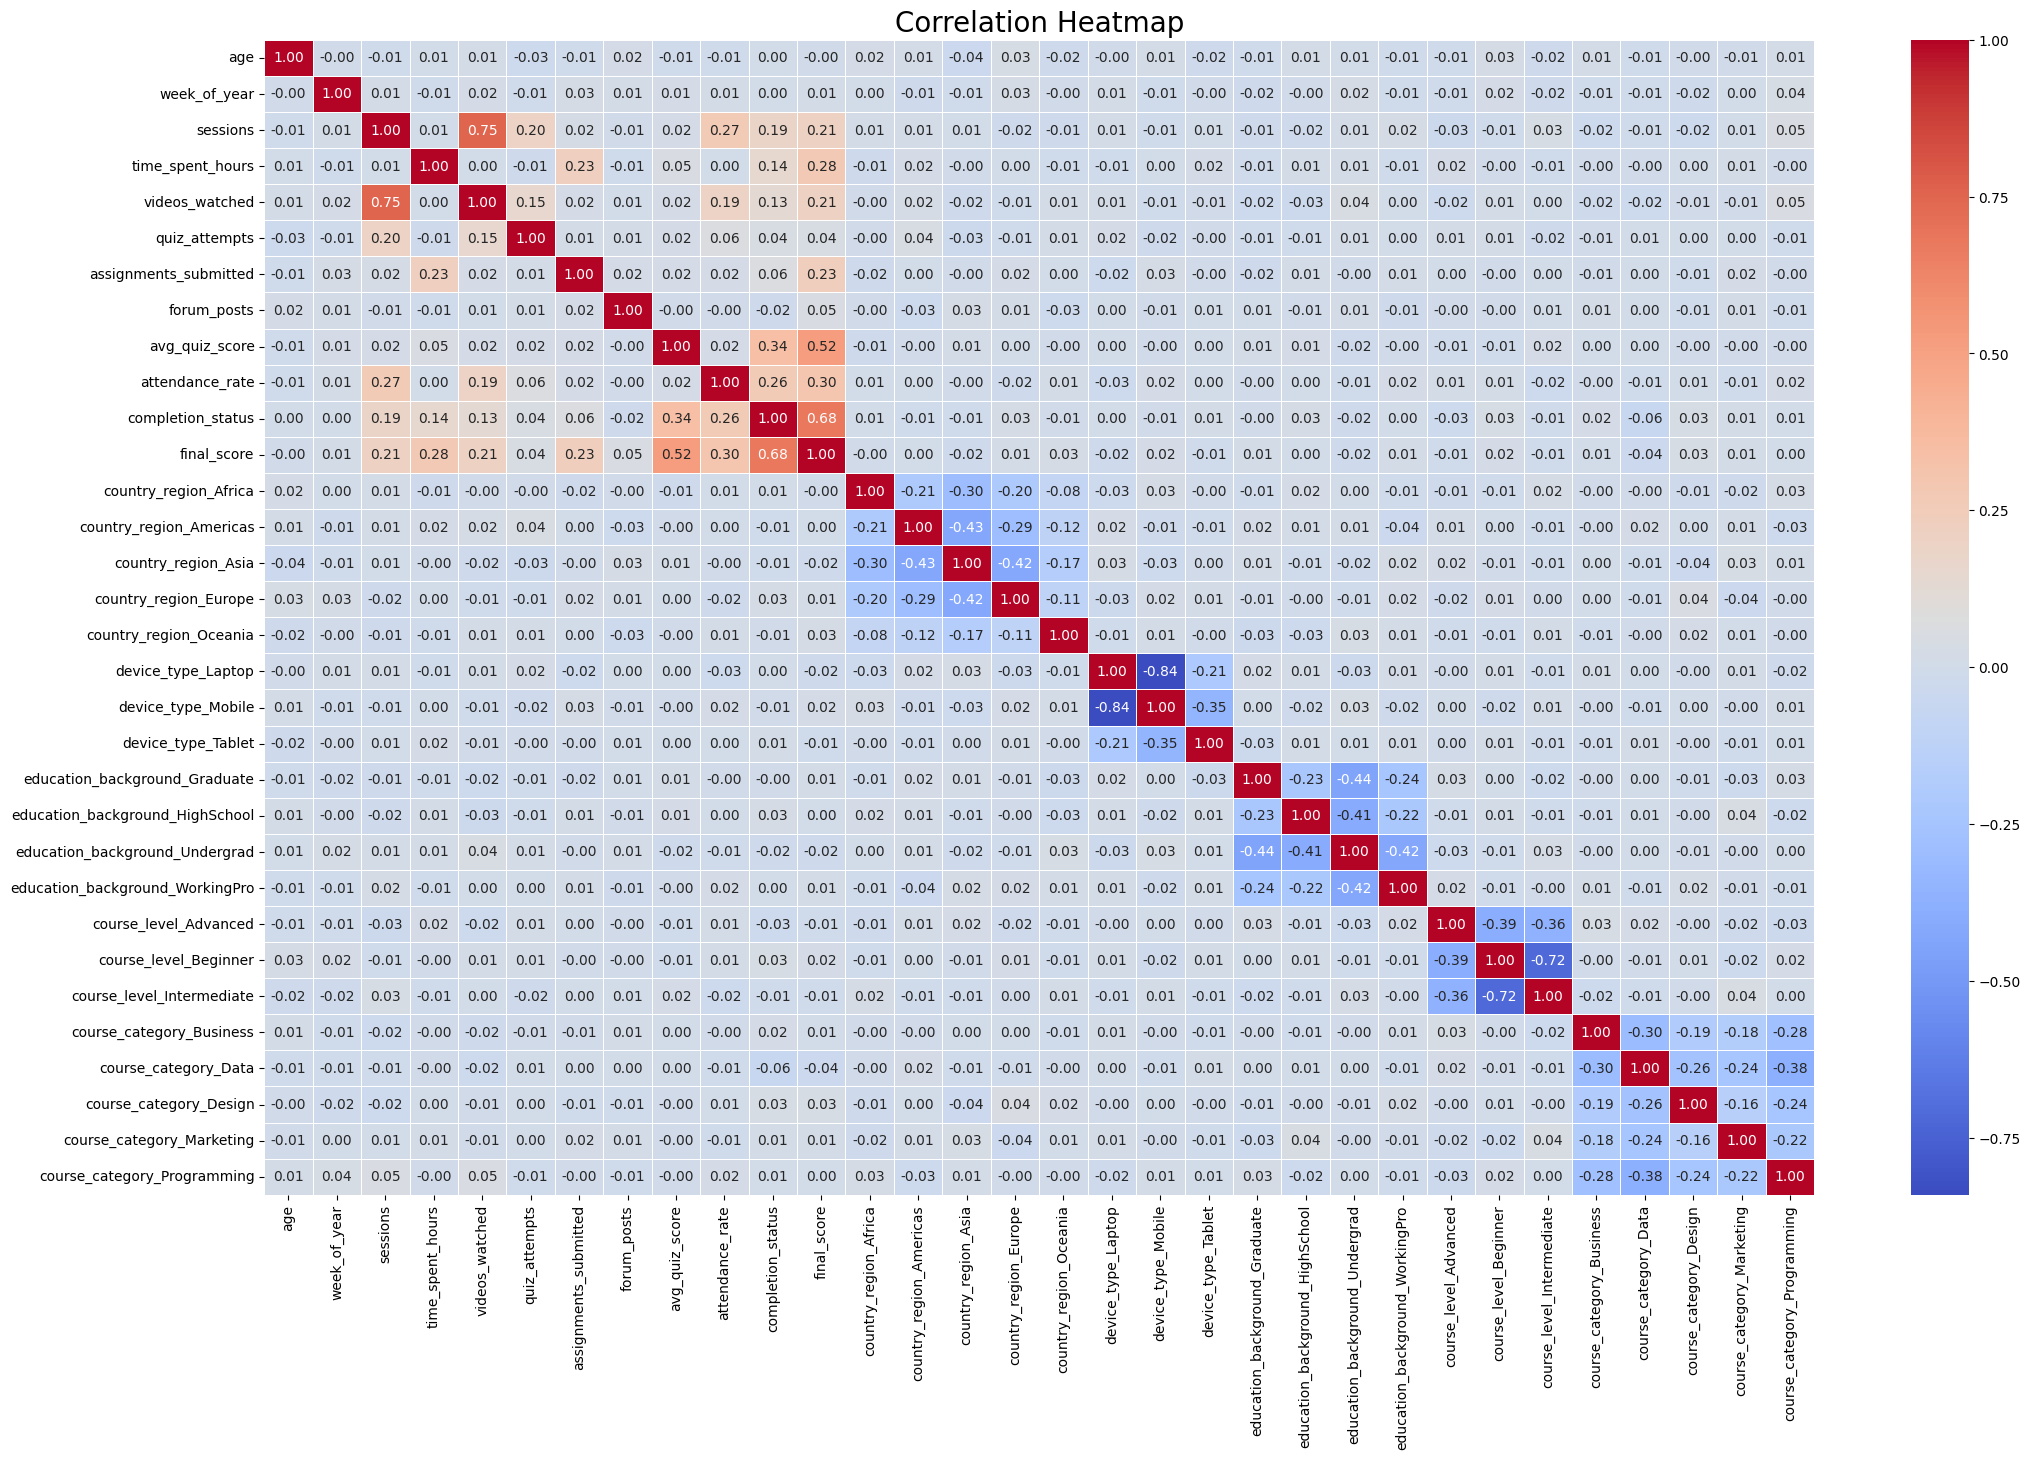

In [37]:
# =====================================================
# Correlation Heatmap
# =====================================================

plt.figure(figsize=(25,15))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=20
)

plt.show()
